In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'font.family': 'serif',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'savefig.dpi': 300,
})

import os
os.makedirs('figures', exist_ok=True)

## Physical Constants

In [2]:
S = 1361.0                  # Solar constant (W/m^2)
ALPHA = 0.3                 # Planetary albedo
SIGMA = 5.670374419e-8      # Stefan-Boltzmann constant (W/m^2/K^4)
T_BASELINE = 287.15         # 1951-1980 global mean baseline temperature (K)

# Derived: absorbed solar radiation per unit area
Q = S * (1 - ALPHA) / 4
print(f"Absorbed solar flux Q = S(1-α)/4 = {Q:.2f} W/m²")

Absorbed solar flux Q = S(1-α)/4 = 238.17 W/m²


## Data Loading

### CO₂ Data — Mauna Loa Observatory (Keeling Curve)

In [3]:
co2_raw = pd.read_csv('co2_mm_mlo.csv', comment='#')
co2_raw.columns = co2_raw.columns.str.strip()

co2_annual_all = co2_raw.groupby('year')['average'].mean().reset_index()
co2_annual_all.columns = ['year', 'co2_annual']

co2_annual = co2_annual_all[(co2_annual_all['year'] >= 1994) & (co2_annual_all['year'] <= 2024)].copy()
co2_annual = co2_annual.reset_index(drop=True)

print(f"CO₂ data: {len(co2_annual)} years, {co2_annual['year'].iloc[0]}–{co2_annual['year'].iloc[-1]}")
print(f"  Range: {co2_annual['co2_annual'].iloc[0]:.1f} → {co2_annual['co2_annual'].iloc[-1]:.1f} ppm")
co2_annual.head()

CO₂ data: 31 years, 1994–2024
  Range: 359.0 → 424.6 ppm


,year,co2_annual
0,1994,358.959167
1,1995,360.968333
2,1996,362.743333
3,1997,363.876667
4,1998,366.840000


### Temperature Data — NASA GISTEMP v4

In [4]:
temp_raw = pd.read_csv('GLB.Ts+dSST.csv', skiprows=1, na_values=['***'])

temp_all = temp_raw[['Year', 'J-D']].dropna().copy()
temp_all.columns = ['year', 'temp_anomaly']

temp_annual = temp_all[(temp_all['year'] >= 1994) & (temp_all['year'] <= 2024)].copy()
temp_annual = temp_annual.reset_index(drop=True)

print(f"Temperature data: {len(temp_annual)} years, {temp_annual['year'].iloc[0]}–{temp_annual['year'].iloc[-1]}")
print(f"  Anomaly range: {temp_annual['temp_anomaly'].min():.2f} → {temp_annual['temp_anomaly'].max():.2f} °C")
temp_annual.head()

Temperature data: 31 years, 1994–2024
  Anomaly range: 0.31 → 1.28 °C


,year,temp_anomaly
0,1994,0.31
1,1995,0.44
2,1996,0.33
3,1997,0.46
4,1998,0.61


### Merge Datasets & Compute Absolute Temperature

In [5]:
df = pd.merge(co2_annual, temp_annual, on='year')
df['temp_abs'] = T_BASELINE + df['temp_anomaly']

print(f"Merged dataset: {len(df)} years")
print(f"  Absolute temperature range: {df['temp_abs'].iloc[0]:.2f} → {df['temp_abs'].iloc[-1]:.2f} K")
df

Merged dataset: 31 years
  Absolute temperature range: 287.46 → 288.43 K


,year,co2_annual,temp_anomaly,temp_abs
0,1994,358.959167,0.31,287.46
1,1995,360.968333,0.44,287.59
2,1996,362.743333,0.33,287.48
3,1997,363.876667,0.46,287.61
4,1998,366.840000,0.61,287.76
5,1999,368.540000,0.38,287.53
6,2000,369.706667,0.39,287.54
7,2001,371.319167,0.53,287.68
8,2002,373.452500,0.63,287.78
9,2003,375.983333,0.61,287.76


## Historical Context Figures

These figures show the full historical record with the 1994–2024 analysis window highlighted.

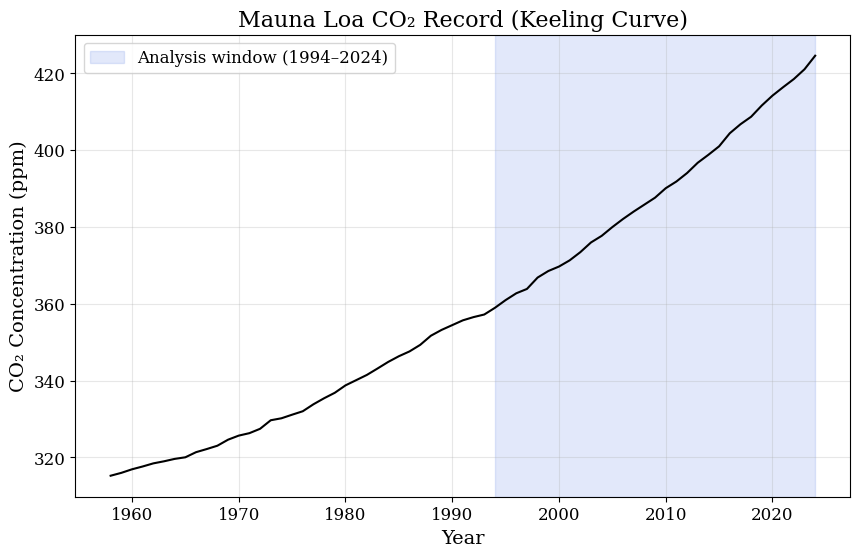

In [6]:
# Full Keeling Curve (1958-2024) with analysis window highlighted
co2_full = co2_annual_all[co2_annual_all['year'] <= 2024]

fig, ax = plt.subplots()
ax.plot(co2_full['year'], co2_full['co2_annual'], 'k-', linewidth=1.5)
ax.axvspan(1994, 2024, alpha=0.15, color='royalblue', label='Analysis window (1994–2024)')
ax.set_xlabel('Year')
ax.set_ylabel('CO₂ Concentration (ppm)')
ax.set_title('Mauna Loa CO₂ Record (Keeling Curve)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('figures/keeling_curve_full.png')
plt.show()

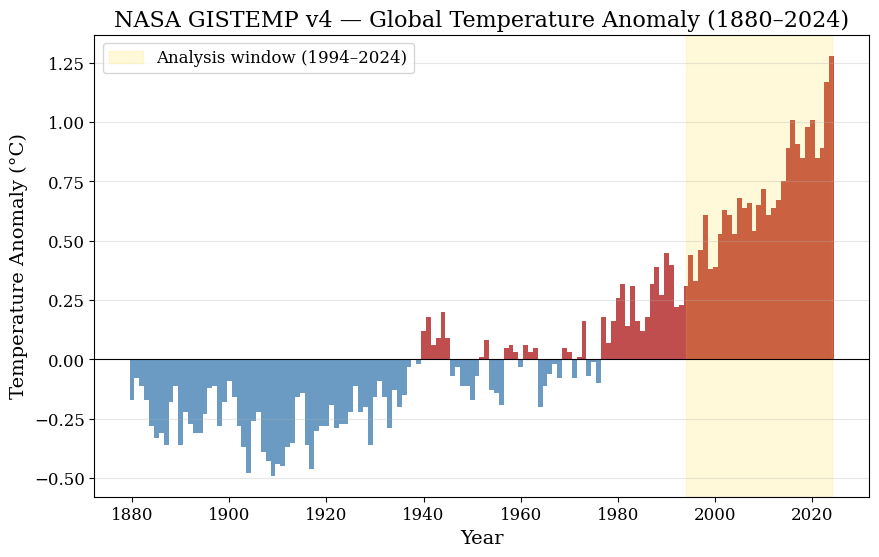

In [7]:
# Full GISTEMP record (1880-2024) with analysis window highlighted
temp_full = temp_all[temp_all['year'] <= 2024]

fig, ax = plt.subplots()
ax.bar(temp_full['year'], temp_full['temp_anomaly'],
       color=np.where(temp_full['temp_anomaly'] >= 0, 'firebrick', 'steelblue'),
       width=1.0, alpha=0.8)
ax.axvspan(1994, 2024, alpha=0.15, color='gold', label='Analysis window (1994–2024)')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('Temperature Anomaly (°C)')
ax.set_title('NASA GISTEMP v4 — Global Temperature Anomaly (1880–2024)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.savefig('figures/gistemp_full.png')
plt.show()

### Dataset Comparison: GISTEMP v4 vs NOAA GlobalTemp v6.1.0

To validate that our results are not an artifact of the choice of temperature dataset, we compare NASA GISTEMP v4 with the independent NOAA GlobalTemp v6.1.0 analysis. NOAA GlobalTemp merges ERSSTv6 (ocean) with GHCNm v4 (land) on a 5°×5° grid.

**Note:** NOAA GlobalTemp uses a 1991–2020 baseline, while GISTEMP uses 1951–1980. We re-baseline the NOAA data to match.

In [8]:
import netCDF4 as nc

noaa_ds = nc.Dataset('NOAAGlobalTemp_v6.1.0_gridded_s185001_e202603_c20260406T114628.nc')
noaa_time = noaa_ds.variables['time']
noaa_dates = nc.num2date(noaa_time[:], noaa_time.units, noaa_time.calendar)
noaa_anom = noaa_ds.variables['anom']
noaa_lats = noaa_ds.variables['lat'][:]

lat_weights = np.cos(np.deg2rad(noaa_lats))

noaa_monthly_gm = []
noaa_years_arr = []
for i, d in enumerate(noaa_dates):
    grid = noaa_anom[i, 0, :, :]
    w = np.broadcast_to(lat_weights[:, np.newaxis], grid.shape)
    noaa_monthly_gm.append(np.average(grid, weights=w))
    noaa_years_arr.append(d.year)

noaa_ds.close()

noaa_years_arr = np.array(noaa_years_arr)
noaa_monthly_gm = np.array(noaa_monthly_gm)

noaa_annual_records = []
for yr in np.unique(noaa_years_arr):
    mask = noaa_years_arr == yr
    if mask.sum() == 12:
        noaa_annual_records.append((yr, noaa_monthly_gm[mask].mean()))

noaa_annual = pd.DataFrame(noaa_annual_records, columns=['year', 'noaa_anom_orig'])

baseline_offset = noaa_annual[
    (noaa_annual['year'] >= 1951) & (noaa_annual['year'] <= 1980)
]['noaa_anom_orig'].mean()
noaa_annual['noaa_anomaly'] = noaa_annual['noaa_anom_orig'] - baseline_offset

print(f"NOAA GlobalTemp v6.1.0:")
print(f"  Record: {noaa_annual['year'].iloc[0]}–{noaa_annual['year'].iloc[-1]} ({len(noaa_annual)} complete years)")
print(f"  Re-baseline offset (1991-2020 → 1951-1980): {baseline_offset:.4f} °C")
print(f"  Anomaly range: {noaa_annual['noaa_anomaly'].min():.2f} to {noaa_annual['noaa_anomaly'].max():.2f} °C")

NOAA GlobalTemp v6.1.0:
  Record: 1850–2025 (176 complete years)
  Re-baseline offset (1991-2020 → 1951-1980): -0.5832 °C
  Anomaly range: -0.45 to 1.23 °C


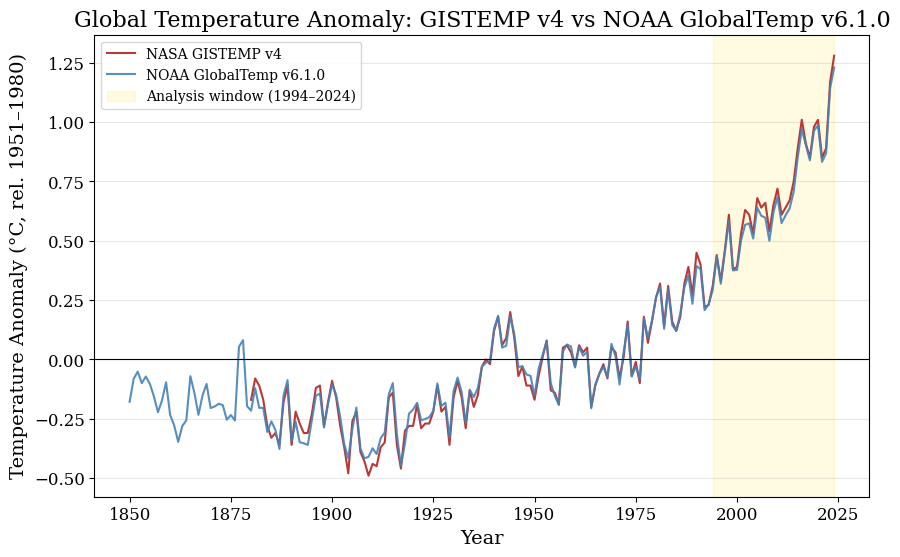

In [9]:
noaa_plot = noaa_annual[noaa_annual['year'] <= 2024]

fig, ax = plt.subplots()
ax.plot(temp_full['year'], temp_full['temp_anomaly'],
        color='firebrick', linewidth=1.5, alpha=0.9, label='NASA GISTEMP v4')
ax.plot(noaa_plot['year'], noaa_plot['noaa_anomaly'],
        color='steelblue', linewidth=1.5, alpha=0.9, label='NOAA GlobalTemp v6.1.0')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.axvspan(1994, 2024, alpha=0.12, color='gold', label='Analysis window (1994–2024)')
ax.set_xlabel('Year')
ax.set_ylabel('Temperature Anomaly (°C, rel. 1951–1980)')
ax.set_title('Global Temperature Anomaly: GISTEMP v4 vs NOAA GlobalTemp v6.1.0')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.savefig('figures/gistemp_vs_noaa.png')
plt.show()

## Energy Balance Model

At radiative equilibrium, absorbed solar radiation equals outgoing longwave radiation:

$$\frac{S(1-\alpha)}{4} = \varepsilon \sigma T^4$$

where $\varepsilon$ is the effective atmospheric emissivity — the fraction of surface radiation that escapes to space. As greenhouse gas concentrations increase, $\varepsilon$ decreases and the surface must warm to restore equilibrium.

In [10]:
# Compute effective emissivity from observed temperatures
df['emissivity'] = Q / (SIGMA * df['temp_abs']**4)

print("Effective emissivity (ε):")
print(f"  1994: {df['emissivity'].iloc[0]:.6f}")
print(f"  2024: {df['emissivity'].iloc[-1]:.6f}")
print(f"  Change: {df['emissivity'].iloc[-1] - df['emissivity'].iloc[0]:.6f}")
df[['year', 'co2_annual', 'temp_anomaly', 'temp_abs', 'emissivity']]

Effective emissivity (ε):
  1994: 0.615141
  2024: 0.606908
  Change: -0.008233


,year,co2_annual,temp_anomaly,temp_abs,emissivity
0,1994,358.959167,0.31,287.46,0.615141
1,1995,360.968333,0.44,287.59,0.614030
2,1996,362.743333,0.33,287.48,0.614970
3,1997,363.876667,0.46,287.61,0.613859
4,1998,366.840000,0.61,287.76,0.612580
5,1999,368.540000,0.38,287.53,0.614542
6,2000,369.706667,0.39,287.54,0.614457
7,2001,371.319167,0.53,287.68,0.613262
8,2002,373.452500,0.63,287.78,0.612410
9,2003,375.983333,0.61,287.76,0.612580


### Nonlinear Regression: ε vs ln(CO₂)

Radiative forcing is logarithmic in CO₂ concentration, so we fit:

$$\varepsilon = a + b \cdot \ln\left(\frac{\text{CO}_2}{\text{CO}_{2,\text{ref}}}\right)$$

where $\text{CO}_{2,\text{ref}}$ is the 1994 annual mean concentration.

In [11]:
co2_ref = df['co2_annual'].iloc[0]

def emissivity_model(co2, a, b):
    return a + b * np.log(co2 / co2_ref)

popt, pcov = curve_fit(emissivity_model, df['co2_annual'].values, df['emissivity'].values)
a_fit, b_fit = popt
a_err, b_err = np.sqrt(np.diag(pcov))

# R-squared
eps_predicted_fit = emissivity_model(df['co2_annual'].values, *popt)
ss_res = np.sum((df['emissivity'].values - eps_predicted_fit)**2)
ss_tot = np.sum((df['emissivity'].values - df['emissivity'].mean())**2)
r_squared = 1 - ss_res / ss_tot

print(f"CO₂ reference (1994): {co2_ref:.2f} ppm")
print(f"Fit: ε = {a_fit:.6f} + ({b_fit:.6f}) × ln(CO₂/{co2_ref:.1f})")
print(f"  a = {a_fit:.6f} ± {a_err:.6f}")
print(f"  b = {b_fit:.6f} ± {b_err:.6f}")
print(f"  R² = {r_squared:.4f}")
print(f"  b is {'negative (correct: ε decreases with CO₂)' if b_fit < 0 else 'POSITIVE (unexpected!)'}")

CO₂ reference (1994): 358.96 ppm
Fit: ε = 0.614812 + (-0.037174) × ln(CO₂/359.0)
  a = 0.614812 ± 0.000276
  b = -0.037174 ± 0.002932
  R² = 0.8471
  b is negative (correct: ε decreases with CO₂)


### Predict Temperature from Fitted Model

In [12]:
def predict_temperature(co2, a, b):
    """Predict absolute temperature from CO2 using the fitted emissivity model."""
    eps = emissivity_model(co2, a, b)
    return (Q / (SIGMA * eps))**0.25

df['temp_predicted'] = predict_temperature(df['co2_annual'].values, a_fit, b_fit)
df['residual'] = df['temp_predicted'] - df['temp_abs']

print(f"Residuals (predicted - observed):")
print(f"  Mean: {df['residual'].mean():.4f} K")
print(f"  Std:  {df['residual'].std():.4f} K")
print(f"  Max absolute: {df['residual'].abs().max():.4f} K")

Residuals (predicted - observed):
  Mean: -0.0001 K
  Std:  0.0939 K
  Max absolute: 0.1969 K


## Equilibrium Climate Sensitivity (ECS)

ECS is defined as the equilibrium temperature change resulting from a doubling of CO₂:

$$\text{ECS} = T(2 \times \text{CO}_{2,\text{ref}}) - T(\text{CO}_{2,\text{ref}})$$

We estimate uncertainty via Monte Carlo sampling from the fitted parameter covariance matrix.

In [13]:
np.random.seed(42)
n_samples = 10_000

samples = np.random.multivariate_normal(popt, pcov, size=n_samples)

ecs_samples = np.array([
    predict_temperature(2 * co2_ref, a_s, b_s) - predict_temperature(co2_ref, a_s, b_s)
    for a_s, b_s in samples
])

ecs_mean = np.mean(ecs_samples)
ecs_ci_lower = np.percentile(ecs_samples, 2.5)
ecs_ci_upper = np.percentile(ecs_samples, 97.5)

T_ref = predict_temperature(co2_ref, a_fit, b_fit)
T_2x = predict_temperature(2 * co2_ref, a_fit, b_fit)
ecs_point = T_2x - T_ref

print(f"Reference CO₂: {co2_ref:.1f} ppm")
print(f"Doubled CO₂:   {2*co2_ref:.1f} ppm")
print(f"T at reference: {T_ref:.2f} K ({T_ref - 273.15:.2f} °C)")
print(f"T at 2×CO₂:    {T_2x:.2f} K ({T_2x - 273.15:.2f} °C)")
print(f"")
print(f"ECS (point estimate): {ecs_point:.2f} °C")
print(f"ECS (Monte Carlo mean): {ecs_mean:.2f} °C")
print(f"ECS (95% CI): [{ecs_ci_lower:.2f}, {ecs_ci_upper:.2f}] °C")
print(f"IPCC likely range: [2.5, 4.0] °C")

Reference CO₂: 359.0 ppm
Doubled CO₂:   717.9 ppm
T at reference: 287.50 K (14.35 °C)
T at 2×CO₂:    290.59 K (17.44 °C)

ECS (point estimate): 3.09 °C
ECS (Monte Carlo mean): 3.09 °C
ECS (95% CI): [2.60, 3.59] °C
IPCC likely range: [2.5, 4.0] °C


## Results Figures

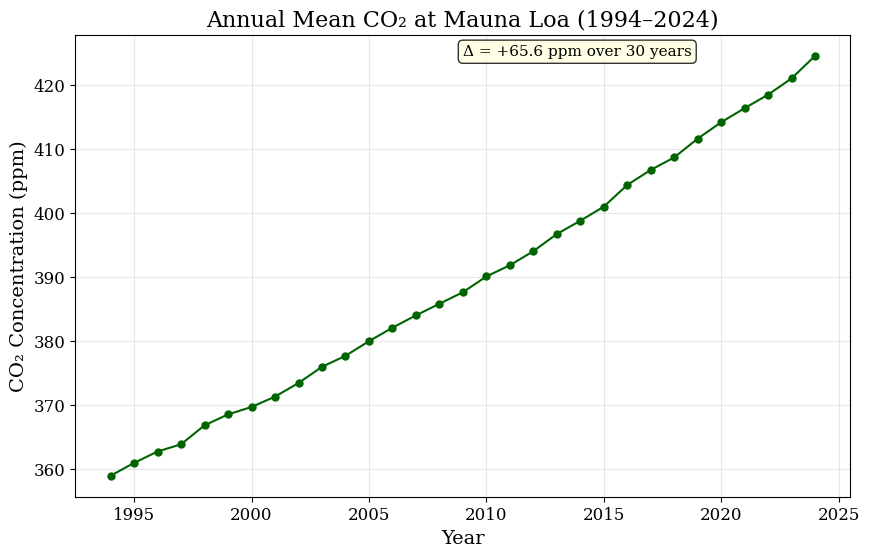

In [14]:
# Figure 1: CO2 time series (1994-2024)
fig, ax = plt.subplots()
ax.plot(df['year'], df['co2_annual'], 'o-', color='darkgreen', markersize=5, linewidth=1.5)
ax.set_xlabel('Year')
ax.set_ylabel('CO₂ Concentration (ppm)')
ax.set_title('Annual Mean CO₂ at Mauna Loa (1994–2024)')
ax.grid(True, alpha=0.3)

co2_change = df['co2_annual'].iloc[-1] - df['co2_annual'].iloc[0]
ax.annotate(f'Δ = +{co2_change:.1f} ppm over 30 years',
            xy=(2009, df['co2_annual'].max()), fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.savefig('figures/co2_timeseries.png')
plt.show()

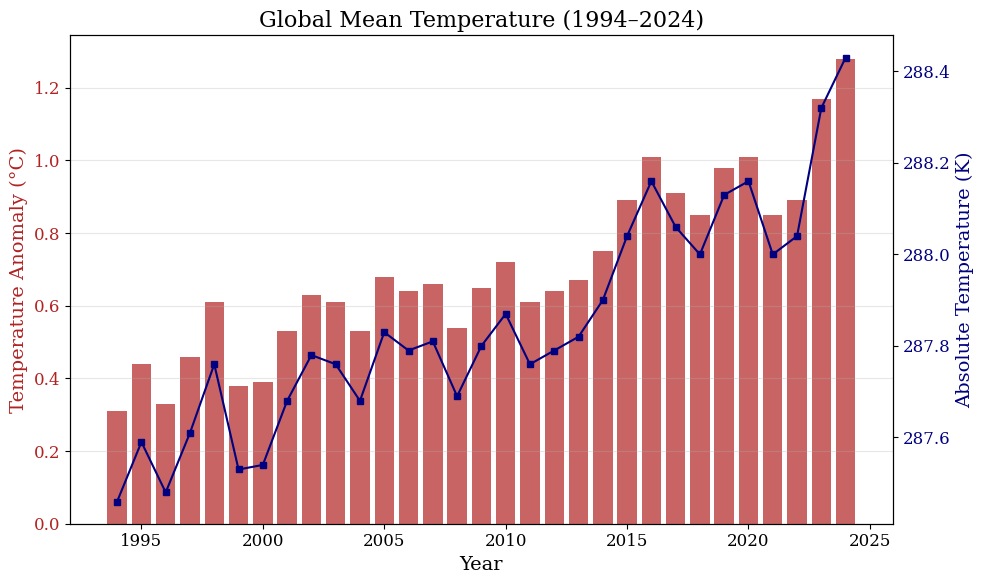

In [15]:
# Figure 2: Temperature time series with dual axis
fig, ax1 = plt.subplots()

color_anom = 'firebrick'
ax1.bar(df['year'], df['temp_anomaly'], color=color_anom, alpha=0.7, width=0.8)
ax1.set_xlabel('Year')
ax1.set_ylabel('Temperature Anomaly (°C)', color=color_anom)
ax1.tick_params(axis='y', labelcolor=color_anom)

ax2 = ax1.twinx()
color_abs = 'navy'
ax2.plot(df['year'], df['temp_abs'], 's-', color=color_abs, markersize=4, linewidth=1.5)
ax2.set_ylabel('Absolute Temperature (K)', color=color_abs)
ax2.tick_params(axis='y', labelcolor=color_abs)

ax1.set_title('Global Mean Temperature (1994–2024)')
ax1.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
plt.savefig('figures/temperature_timeseries.png')
plt.show()

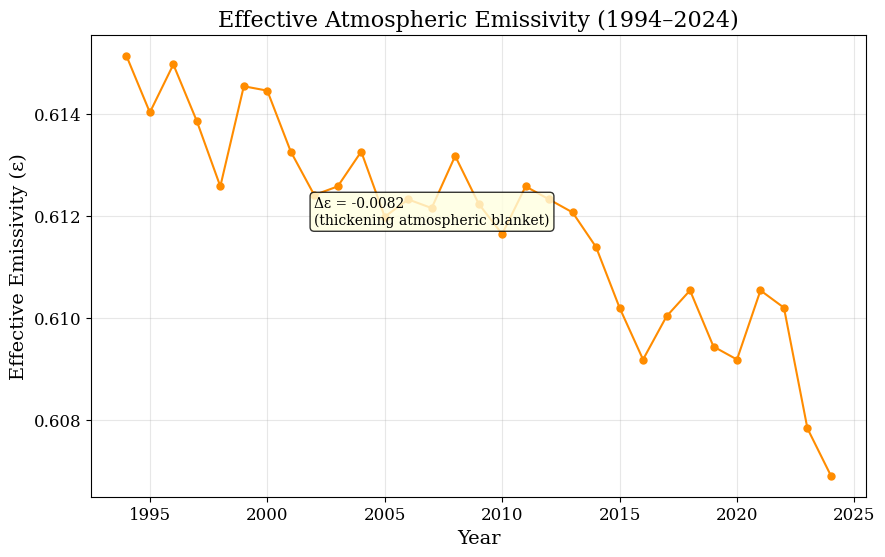

In [16]:
# Figure 3: Emissivity time series
fig, ax = plt.subplots()
ax.plot(df['year'], df['emissivity'], 'o-', color='darkorange', markersize=5, linewidth=1.5)
ax.set_xlabel('Year')
ax.set_ylabel('Effective Emissivity (ε)')
ax.set_title('Effective Atmospheric Emissivity (1994–2024)')
ax.grid(True, alpha=0.3)

eps_change = df['emissivity'].iloc[-1] - df['emissivity'].iloc[0]
ax.annotate(f'Δε = {eps_change:.4f}\n(thickening atmospheric blanket)',
            xy=(2002, df['emissivity'].mean()), fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.savefig('figures/emissivity_timeseries.png')
plt.show()

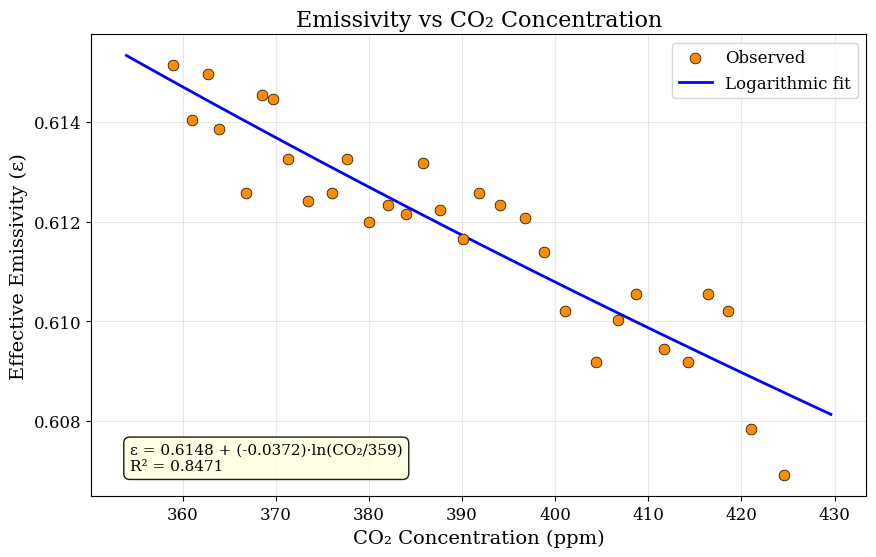

In [17]:
# Figure 4: Emissivity vs CO2 scatter + fit (core scientific result)
co2_smooth = np.linspace(df['co2_annual'].min() - 5, df['co2_annual'].max() + 5, 200)
eps_smooth = emissivity_model(co2_smooth, a_fit, b_fit)

fig, ax = plt.subplots()
ax.scatter(df['co2_annual'], df['emissivity'], c='darkorange', s=60, edgecolors='black',
           linewidths=0.5, zorder=5, label='Observed')
ax.plot(co2_smooth, eps_smooth, 'b-', linewidth=2, label='Logarithmic fit')
ax.set_xlabel('CO₂ Concentration (ppm)')
ax.set_ylabel('Effective Emissivity (ε)')
ax.set_title('Emissivity vs CO₂ Concentration')
ax.legend()
ax.grid(True, alpha=0.3)

eq_text = f'ε = {a_fit:.4f} + ({b_fit:.4f})·ln(CO₂/{co2_ref:.0f})\nR² = {r_squared:.4f}'
ax.annotate(eq_text, xy=(0.05, 0.05), xycoords='axes fraction', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.9),
            verticalalignment='bottom')

plt.savefig('figures/emissivity_vs_co2.png')
plt.show()

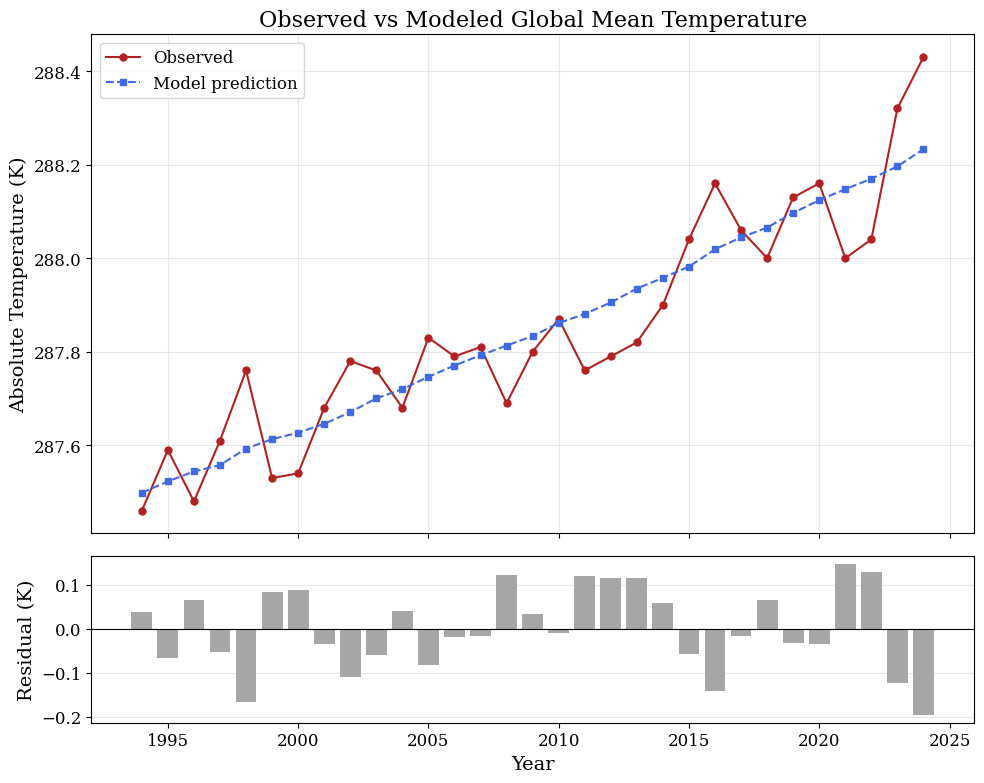

In [18]:
# Figure 5: Model vs observed temperature + residuals
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[3, 1], sharex=True)

ax1.plot(df['year'], df['temp_abs'], 'o-', color='firebrick', markersize=5, label='Observed')
ax1.plot(df['year'], df['temp_predicted'], 's--', color='royalblue', markersize=5, label='Model prediction')
ax1.set_ylabel('Absolute Temperature (K)')
ax1.set_title('Observed vs Modeled Global Mean Temperature')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.bar(df['year'], df['residual'], color='gray', alpha=0.7, width=0.8)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_xlabel('Year')
ax2.set_ylabel('Residual (K)')
ax2.grid(True, alpha=0.3, axis='y')

fig.tight_layout()
plt.savefig('figures/model_vs_observed.png')
plt.show()

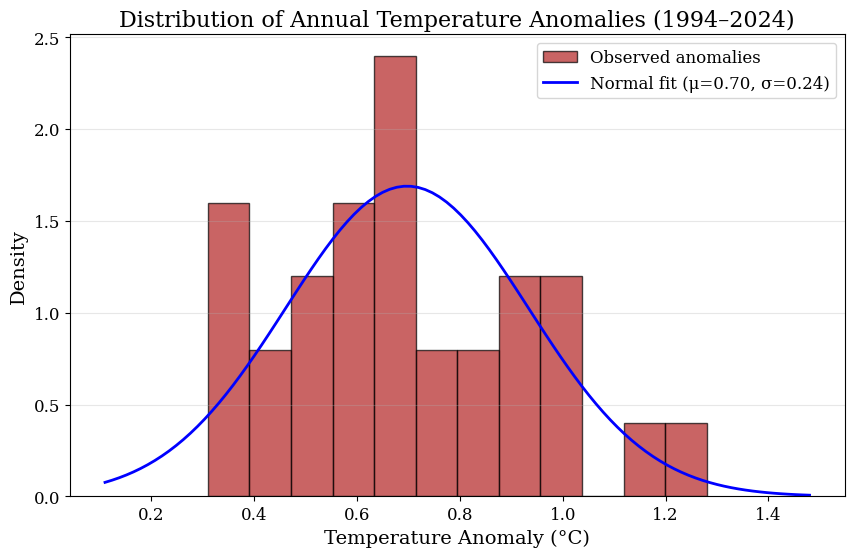

In [19]:
# Figure 6: Temperature anomaly histogram
fig, ax = plt.subplots()
n, bins, patches = ax.hist(df['temp_anomaly'], bins=12, color='firebrick', alpha=0.7,
                            edgecolor='black', density=True, label='Observed anomalies')

mu, std = norm.fit(df['temp_anomaly'])
x = np.linspace(df['temp_anomaly'].min() - 0.2, df['temp_anomaly'].max() + 0.2, 100)
ax.plot(x, norm.pdf(x, mu, std), 'b-', linewidth=2,
        label=f'Normal fit (μ={mu:.2f}, σ={std:.2f})')

ax.set_xlabel('Temperature Anomaly (°C)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Annual Temperature Anomalies (1994–2024)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.savefig('figures/anomaly_histogram.png')
plt.show()

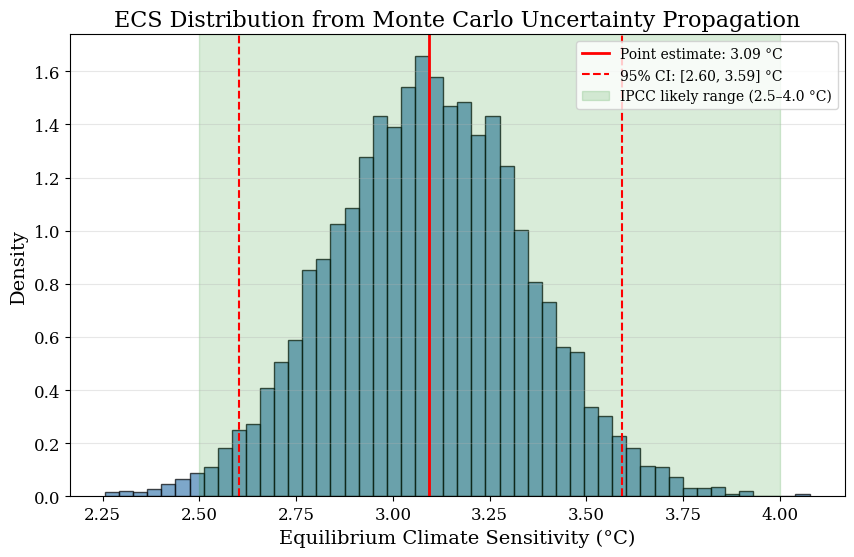

In [20]:
# Figure 7: ECS Monte Carlo distribution
fig, ax = plt.subplots()
ax.hist(ecs_samples, bins=50, color='steelblue', alpha=0.7, edgecolor='black', density=True)

ax.axvline(ecs_point, color='red', linewidth=2, linestyle='-', label=f'Point estimate: {ecs_point:.2f} °C')
ax.axvline(ecs_ci_lower, color='red', linewidth=1.5, linestyle='--', label=f'95% CI: [{ecs_ci_lower:.2f}, {ecs_ci_upper:.2f}] °C')
ax.axvline(ecs_ci_upper, color='red', linewidth=1.5, linestyle='--')

ax.axvspan(2.5, 4.0, alpha=0.15, color='green', label='IPCC likely range (2.5–4.0 °C)')

ax.set_xlabel('Equilibrium Climate Sensitivity (°C)')
ax.set_ylabel('Density')
ax.set_title('ECS Distribution from Monte Carlo Uncertainty Propagation')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.savefig('figures/ecs_distribution.png')
plt.show()

## Summary of Results

In [21]:
print("=" * 60)
print("SUMMARY OF RESULTS")
print("=" * 60)
print()
print("DATA (1994–2024)")
print(f"  CO₂ range:           {df['co2_annual'].iloc[0]:.1f} – {df['co2_annual'].iloc[-1]:.1f} ppm")
print(f"  CO₂ increase:        +{co2_change:.1f} ppm ({co2_change/df['co2_annual'].iloc[0]*100:.1f}%)")
print(f"  Temp anomaly range:  +{df['temp_anomaly'].min():.2f} – +{df['temp_anomaly'].max():.2f} °C")
print(f"  Absolute temp range: {df['temp_abs'].min():.2f} – {df['temp_abs'].max():.2f} K")
print()
print("ENERGY BALANCE MODEL")
print(f"  Emissivity range:    {df['emissivity'].max():.6f} – {df['emissivity'].min():.6f}")
print(f"  Emissivity change:   {eps_change:.6f}")
print()
print("REGRESSION FIT")
print(f"  ε = {a_fit:.6f} + ({b_fit:.6f}) × ln(CO₂/{co2_ref:.0f})")
print(f"  a = {a_fit:.6f} ± {a_err:.6f}")
print(f"  b = {b_fit:.6f} ± {b_err:.6f}")
print(f"  R² = {r_squared:.4f}")
print(f"  Residual RMSE: {np.sqrt(np.mean(df['residual']**2)):.4f} K")
print()
print("EQUILIBRIUM CLIMATE SENSITIVITY")
print(f"  ECS (point estimate):    {ecs_point:.2f} °C")
print(f"  ECS (Monte Carlo mean):  {ecs_mean:.2f} °C")
print(f"  ECS (95% CI):            [{ecs_ci_lower:.2f}, {ecs_ci_upper:.2f}] °C")
print(f"  IPCC AR6 likely range:   [2.5, 4.0] °C")
print("=" * 60)

SUMMARY OF RESULTS

DATA (1994–2024)
  CO₂ range:           359.0 – 424.6 ppm
  CO₂ increase:        +65.6 ppm (18.3%)
  Temp anomaly range:  +0.31 – +1.28 °C
  Absolute temp range: 287.46 – 288.43 K

ENERGY BALANCE MODEL
  Emissivity range:    0.615141 – 0.606908
  Emissivity change:   -0.008233

REGRESSION FIT
  ε = 0.614812 + (-0.037174) × ln(CO₂/359)
  a = 0.614812 ± 0.000276
  b = -0.037174 ± 0.002932
  R² = 0.8471
  Residual RMSE: 0.0924 K

EQUILIBRIUM CLIMATE SENSITIVITY
  ECS (point estimate):    3.09 °C
  ECS (Monte Carlo mean):  3.09 °C
  ECS (95% CI):            [2.60, 3.59] °C
  IPCC AR6 likely range:   [2.5, 4.0] °C
